<a href="https://colab.research.google.com/github/SantiagoMendivelso01/rappi_dashboard/blob/main/Rappi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, zipfile, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime
from google.colab import files

In [2]:
print("Sube el archivo ZIP")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
print(f"Subido: {zip_name}")

Sube el archivo ZIP


Saving Archivo.zip to Archivo.zip
Subido: Archivo.zip


In [3]:
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("data/")

csv_files = [
    f for f in glob.glob("data/**/*.csv", recursive=True)
    if "__MACOSX" not in f
]

print(f"Total de archivos CSV encontrados: {len(csv_files)}")
print(f"\nEjemplos de nombres:")
for f in csv_files[:5]:
    print(f"  {os.path.basename(f)}")

Total de archivos CSV encontrados: 201

Ejemplos de nombres:
  AVAILABILITY-data (28).csv
  AVAILABILITY-data (50).csv
  AVAILABILITY-data (93).csv
  AVAILABILITY-data - 2026-02-11T161038.880.csv
  AVAILABILITY-data (55).csv


In [4]:
sample_file = csv_files[0]
print(f"Inspeccionando: {os.path.basename(sample_file)}")

with open(sample_file) as f:
    lines = f.readlines()
    print(f"  Líneas totales (incluyendo header): {len(lines)}")
    print(f"  Header (primeras 6 columnas): {lines[0].split(',')[:6]}")
    print(f"  Fila de datos (primeros 6 valores): {lines[1].split(',')[:6]}")

import csv
with open(sample_file) as f:
    reader = csv.reader(f)
    header = next(reader)
    data_row = next(reader)

ts_columns = header[4:]
print(f"\n  Timestamps por archivo: {len(ts_columns)}")
print(f"  Primer timestamp: {ts_columns[0]}")
print(f"  Último timestamp: {ts_columns[-1]}")
print(f"  Métrica: {data_row[1]}")
print(f"  Valor sample: {data_row[4]}")

Inspeccionando: AVAILABILITY-data (28).csv
  Líneas totales (incluyendo header): 2
  Header (primeras 6 columnas): ['Plot name', 'metric (sf_metric)', 'Value Prefix', 'Value Suffix', 'Mon Feb 02 2026 14:59:40 GMT-0500 (hora estándar de Colombia)', 'Mon Feb 02 2026 14:59:50 GMT-0500 (hora estándar de Colombia)']
  Fila de datos (primeros 6 valores): ['NOW', 'synthetic_monitoring_visible_stores', '', '', '4388794', '4390651']

  Timestamps por archivo: 363
  Primer timestamp: Mon Feb 02 2026 14:59:40 GMT-0500 (hora estándar de Colombia)
  Último timestamp: Mon Feb 02 2026 16:00:00 GMT-0500 (hora estándar de Colombia)
  Métrica: synthetic_monitoring_visible_stores
  Valor sample: 4388794


In [5]:
def parse_rappi_timestamp(ts_str):
    """
    Convierte 'Wed Feb 11 2026 14:00:00 GMT-0500 (hora estándar de Colombia)'
    a datetime UTC-5 (Colombia).
    """
    # Extraer solo la parte relevante: 'Wed Feb 11 2026 14:00:00'
    clean = ts_str.strip().split(" GMT")[0]
    return datetime.strptime(clean, "%a %b %d %Y %H:%M:%S")


def parse_csv_file(filepath):
    records = {}
    try:
        with open(filepath, encoding="utf-8") as f:
            reader = csv.reader(f)
            header = next(reader)  # inicia desde la columna 4 que es desde donde hay informacion util
            ts_cols = header[4:]

            for row in reader:
                if len(row) < 5:
                    continue
                metric = row[1]
                if metric == "metric (sf_metric)":
                    continue
                values = row[4:]
                for ts_str, val_str in zip(ts_cols, values):
                    try:
                        ts = parse_rappi_timestamp(ts_str)
                        val = float(val_str) if val_str.strip() else np.nan
                        records[ts] = val
                    except Exception:
                        continue
    except Exception as e:
        print(f"Error{os.path.basename(filepath)}: {e}")
    return records

all_records = {}

for i, filepath in enumerate(csv_files):
    file_records = parse_csv_file(filepath)
    all_records.update(file_records)
    if (i + 1) % 20 == 0:
        print(f"  Procesados {i+1}/{len(csv_files)} archivos — {len(all_records):,} datapoints únicos")

print(f"Parseo completo")
print(f"Total datapoints únicos: {len(all_records):,}")

  Procesados 20/201 archivos — 7,126 datapoints únicos
  Procesados 40/201 archivos — 14,338 datapoints únicos
  Procesados 60/201 archivos — 20,788 datapoints únicos
  Procesados 80/201 archivos — 27,492 datapoints únicos
  Procesados 100/201 archivos — 33,913 datapoints únicos
  Procesados 120/201 archivos — 39,998 datapoints únicos
  Procesados 140/201 archivos — 46,862 datapoints únicos
  Procesados 160/201 archivos — 53,260 datapoints únicos
  Procesados 180/201 archivos — 59,772 datapoints únicos
  Procesados 200/201 archivos — 66,784 datapoints únicos
Parseo completo
Total datapoints únicos: 67,141


In [6]:
parsed_data = pd.Series(all_records)
print("Prentradas:\n", parsed_data.head(10))

Prentradas:
 2026-02-02 14:59:40    4388794.0
2026-02-02 14:59:50    4390651.0
2026-02-02 15:00:00    4393300.0
2026-02-02 15:00:10    4396329.0
2026-02-02 15:00:20    4401191.0
2026-02-02 15:00:30    4407003.0
2026-02-02 15:00:40    4411526.0
2026-02-02 15:00:50    4416413.0
2026-02-02 15:01:00    4422143.0
2026-02-02 15:01:10    4427090.0
dtype: float64


In [7]:
df = pd.DataFrame(
    list(all_records.items()),
    columns=["timestamp", "visible_stores"]
)
df = df.sort_values("timestamp").reset_index(drop=True)

print("DataFrame:")
print(f"   Shape: {df.shape}")
print(f"   Rango: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"   Nulos: {df['visible_stores'].isna().sum()}")
print()
print(df.head(10))
print(df.tail(10))

DataFrame:
   Shape: (67141, 2)
   Rango: 2026-02-01 06:11:20 → 2026-02-11 15:00:00
   Nulos: 0

            timestamp  visible_stores
0 2026-02-01 06:11:20            37.0
1 2026-02-01 06:11:30           195.0
2 2026-02-01 06:11:40           451.0
3 2026-02-01 06:11:50           489.0
4 2026-02-01 06:12:00           911.0
5 2026-02-01 06:12:10          1047.0
6 2026-02-01 06:12:20          1268.0
7 2026-02-01 06:12:30          1704.0
8 2026-02-01 06:12:40          1759.0
9 2026-02-01 06:12:50          2118.0
                timestamp  visible_stores
67131 2026-02-11 14:58:30       5611436.0
67132 2026-02-11 14:58:40       5620891.0
67133 2026-02-11 14:58:50       5626383.0
67134 2026-02-11 14:59:00       5619385.0
67135 2026-02-11 14:59:10       5622688.0
67136 2026-02-11 14:59:20       5617700.0
67137 2026-02-11 14:59:30       5628304.0
67138 2026-02-11 14:59:40       5636017.0
67139 2026-02-11 14:59:50       5629053.0
67140 2026-02-11 15:00:00       5630566.0


In [8]:
df["diff_seconds"] = df["timestamp"].diff().dt.total_seconds()

print("Análisis de gaps entre datapoints:")
print(f"Intervalo esperado: 10 segundos")
print(f"Intervalo mediana:  {df['diff_seconds'].median():.0f} segundos")
print(f"Intervalo máximo:   {df['diff_seconds'].max():.0f} segundos")
print(f"Intervalo mínimo:   {df['diff_seconds'].min():.0f} segundos")

gaps = df[df["diff_seconds"] > 60].copy()
print(f"\n   Gaps > 1 minuto: {len(gaps)}")
if len(gaps) > 0:
    print("\n   Gaps más grandes:")
    print(
        gaps.nlargest(10, "diff_seconds")[["timestamp", "diff_seconds"]]
        .to_string(index=False)
    )


Análisis de gaps entre datapoints:
Intervalo esperado: 10 segundos
Intervalo mediana:  10 segundos
Intervalo máximo:   22280 segundos
Intervalo mínimo:   10 segundos

   Gaps > 1 minuto: 17

   Gaps más grandes:
          timestamp  diff_seconds
2026-02-05 06:11:20       22280.0
2026-02-07 06:11:30       21910.0
2026-02-08 06:11:30       21910.0
2026-02-02 06:11:20       21900.0
2026-02-04 06:11:20       21900.0
2026-02-03 06:11:20       21890.0
2026-02-06 06:11:20       21890.0
2026-02-09 06:11:20       21890.0
2026-02-10 06:11:20       21890.0
2026-02-11 06:11:20       21890.0


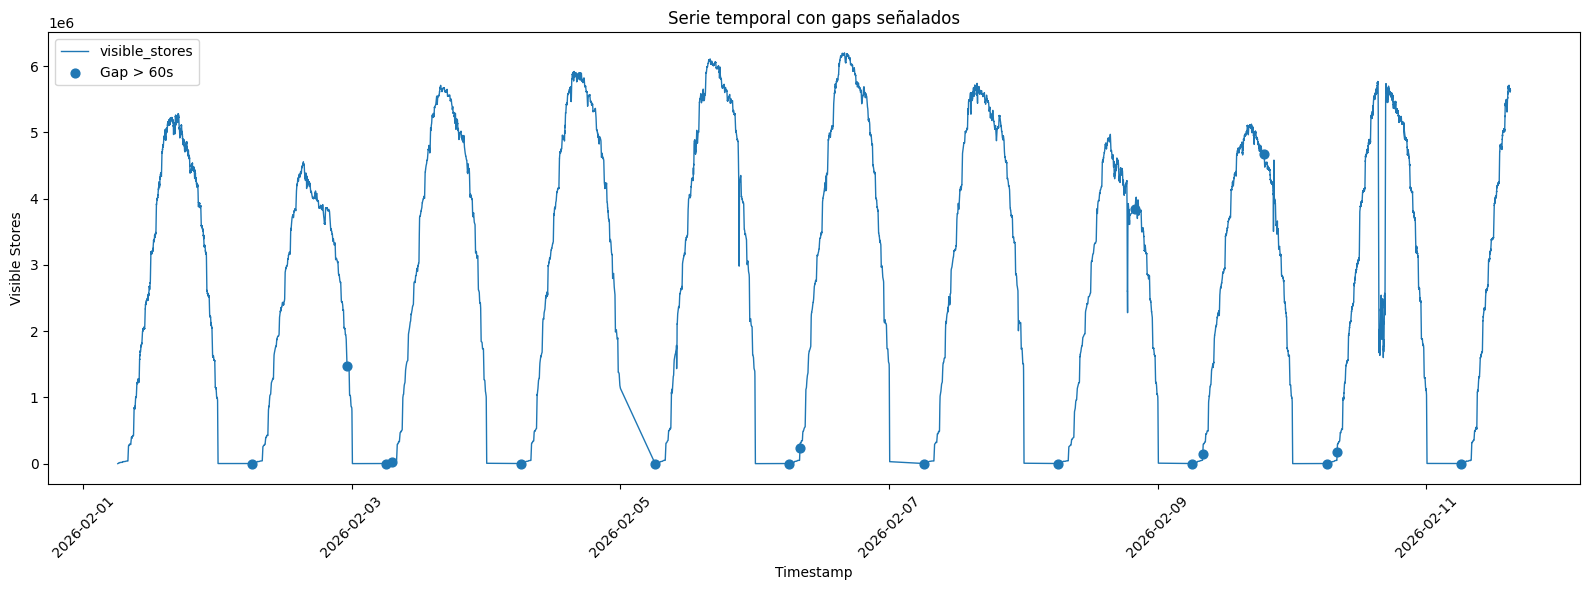

In [9]:
plt.figure(figsize=(16,6))
plt.plot(df["timestamp"], df["visible_stores"], linewidth=1, label="visible_stores")

if len(gaps) > 0:
    plt.scatter(
        gaps["timestamp"],
        gaps["visible_stores"],
        s=40,
        label="Gap > 60s"
    )

plt.title("Serie temporal con gaps señalados")
plt.xlabel("Timestamp")
plt.ylabel("Visible Stores")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
df = df.drop_duplicates(subset=["timestamp"])

In [11]:
full_index = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="10s"
)
df = df.set_index("timestamp").reindex(full_index)
df.index.name = "timestamp"
df = df.reset_index()

missing_count = df["visible_stores"].isna().sum()
total_count = len(df)
print(f"Reindexado a 10s:")
print(f"Total esperado: {total_count:,} datapoints")
print(f"Faltantes:      {missing_count:,} ({missing_count/total_count*100:.2f}%)")

Reindexado a 10s:
Total esperado: 89,573 datapoints
Faltantes:      22,432 (25.04%)


In [12]:
df["visible_stores_raw"] = df["visible_stores"].copy()
df["visible_stores"] = df["visible_stores"].interpolate(method="linear")
df["is_interpolated"] = df["visible_stores_raw"].isna()

In [13]:
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["day_of_week"] = df["timestamp"].dt.day_name()
df["day_of_week_num"] = df["timestamp"].dt.dayofweek
df["date_str"] = df["timestamp"].dt.strftime("%d %b")

In [14]:
df["stores_M"] = df["visible_stores"]

print("DataFrame limpio")
print(df.dtypes)
print()
print(df.head(5))

DataFrame limpio
timestamp             datetime64[ns]
visible_stores               float64
diff_seconds                 float64
visible_stores_raw           float64
is_interpolated                 bool
date                          object
hour                           int32
minute                         int32
day_of_week                   object
day_of_week_num                int32
date_str                      object
stores_M                     float64
dtype: object

            timestamp  visible_stores  diff_seconds  visible_stores_raw  \
0 2026-02-01 06:11:20            37.0           NaN                37.0   
1 2026-02-01 06:11:30           195.0          10.0               195.0   
2 2026-02-01 06:11:40           451.0          10.0               451.0   
3 2026-02-01 06:11:50           489.0          10.0               489.0   
4 2026-02-01 06:12:00           911.0          10.0               911.0   

   is_interpolated        date  hour  minute day_of_week  day_of_week_num

In [15]:
print("Estadistica Descriptiva")


stats = df["visible_stores"].describe()
print(f"Registros totales:   {len(df):,}")
print(f"Días cubiertos:      {df['date'].nunique()}")
print(f"Rango temporal:      {df['timestamp'].min().strftime('%d %b %Y %H:%M')} → "
      f"{df['timestamp'].max().strftime('%d %b %Y %H:%M')}")
print(f"Promedio:            {stats['mean']:>15,.0f} tiendas")
print(f"Mediana:             {stats['50%']:>15,.0f} tiendas")
print(f"Std Dev:             {stats['std']:>15,.0f}")
print(f"Mínimo:              {stats['min']:>15,.0f}  ← {df.loc[df['visible_stores'].idxmin(), 'timestamp']}")
print(f"Máximo:              {stats['max']:>15,.0f}  ← {df.loc[df['visible_stores'].idxmax(), 'timestamp']}")
print(f"Coef. Variación:     {stats['std']/stats['mean']*100:.2f}%")

Estadistica Descriptiva
Registros totales:   89,573
Días cubiertos:      11
Rango temporal:      01 Feb 2026 06:11 → 11 Feb 2026 15:00
Promedio:                  2,436,484 tiendas
Mediana:                   2,355,989 tiendas
Std Dev:                   2,145,275
Mínimo:                            0  ← 2026-02-03 06:11:20
Máximo:                    6,198,472  ← 2026-02-06 16:01:10
Coef. Variación:     88.05%


In [19]:
WINDOW = 6
df["pct_change_1min"] = df["visible_stores"].pct_change(periods=WINDOW) * 100
df["pct_change_10s"] = df["visible_stores"].pct_change(periods=1) * 100

DROP_THRESHOLD = -1.0
SPIKE_THRESHOLD = 1.0

anomalies_drop = df[df["pct_change_1min"] < DROP_THRESHOLD].copy()
anomalies_spike = df[df["pct_change_1min"] > SPIKE_THRESHOLD].copy()

print(f"Detección de anomalías (umbral: ±1% en 1 minuto):")
print(f"Caídas detectadas:   {len(anomalies_drop):,}")
print(f"Subidas detectadas:  {len(anomalies_spike):,}")

print(f"\n   Top 10 caídas más bruscas:")
top_drops = anomalies_drop.nsmallest(10, "pct_change_1min")[
    ["timestamp", "visible_stores", "pct_change_1min"]
].copy()
top_drops.columns = ["Timestamp", "Tiendas Visibles", "Cambio % (1min)"]
top_drops["Cambio % (1min)"] = top_drops["Cambio % (1min)"].map("{:.2f}%".format)
print(top_drops.to_string(index=False))

df["rolling_mean_5m"] = df["visible_stores"].rolling(window=30, center=True).mean()
df["rolling_std_5m"] = df["visible_stores"].rolling(window=30, center=True).std()
df["upper_band"] = df["rolling_mean_5m"] + 2 * df["rolling_std_5m"]
df["lower_band"] = df["rolling_mean_5m"] - 2 * df["rolling_std_5m"]
df["is_outlier"] = (
    (df["visible_stores"] > df["upper_band"]) |
    (df["visible_stores"] < df["lower_band"])
)

print(f"Outliers estadísticos (±2σ rolling 5min): {df['is_outlier'].sum():,}")

Detección de anomalías (umbral: ±1% en 1 minuto):
Caídas detectadas:   8,985
Subidas detectadas:  9,283

   Top 10 caídas más bruscas:
          Timestamp  Tiendas Visibles Cambio % (1min)
2026-02-03 06:11:20               0.0        -100.00%
2026-02-04 06:11:20               0.0        -100.00%
2026-02-05 06:11:20               0.0        -100.00%
2026-02-06 00:06:30               0.0        -100.00%
2026-02-06 00:06:40               0.0        -100.00%
2026-02-06 00:06:50               0.0        -100.00%
2026-02-06 00:07:00               0.0        -100.00%
2026-02-06 00:07:10               0.0        -100.00%
2026-02-06 00:07:20               0.0        -100.00%
2026-02-10 00:06:30               0.0        -100.00%
Outliers estadísticos (±2σ rolling 5min): 2,352


In [21]:
import matplotlib.ticker as mtick

Resumen por día
      date         mean    median   min       max          std  count     range         cv
2026-02-01 3.022546e+06 3370193.5  37.0 5280107.0 1.783000e+06   6412 5280070.0  58.990017
2026-02-02 1.951141e+06 1930940.5  28.0 4554582.0 1.706398e+06   8640 4554554.0  87.456416
2026-02-03 2.508495e+06 2402046.5   0.0 5708166.0 2.226818e+06   8640 5708166.0  88.771056
2026-02-04 2.632562e+06 2590236.5   0.0 5917626.0 2.320352e+06   8640 5917626.0  88.140442
2026-02-05 2.865579e+06 2739492.5   0.0 6107574.0 2.246089e+06   8640 6107574.0  78.381698
2026-02-06 2.770382e+06 2765445.5   0.0 6198472.0 2.432595e+06   8640 6198472.0  87.807190
2026-02-07 2.602155e+06 2614758.5 155.0 5738300.0 2.261427e+06   8640 5738145.0  86.905927
2026-02-08 2.090853e+06 2102094.5 101.0 4969210.0 1.834126e+06   8640 4969109.0  87.721450
2026-02-09 2.288343e+06 2275028.5  22.0 5122526.0 2.002202e+06   8640 5122504.0  87.495721
2026-02-10 2.390832e+06 2140814.5   0.0 5767000.0 2.165503e+06   8640 5767

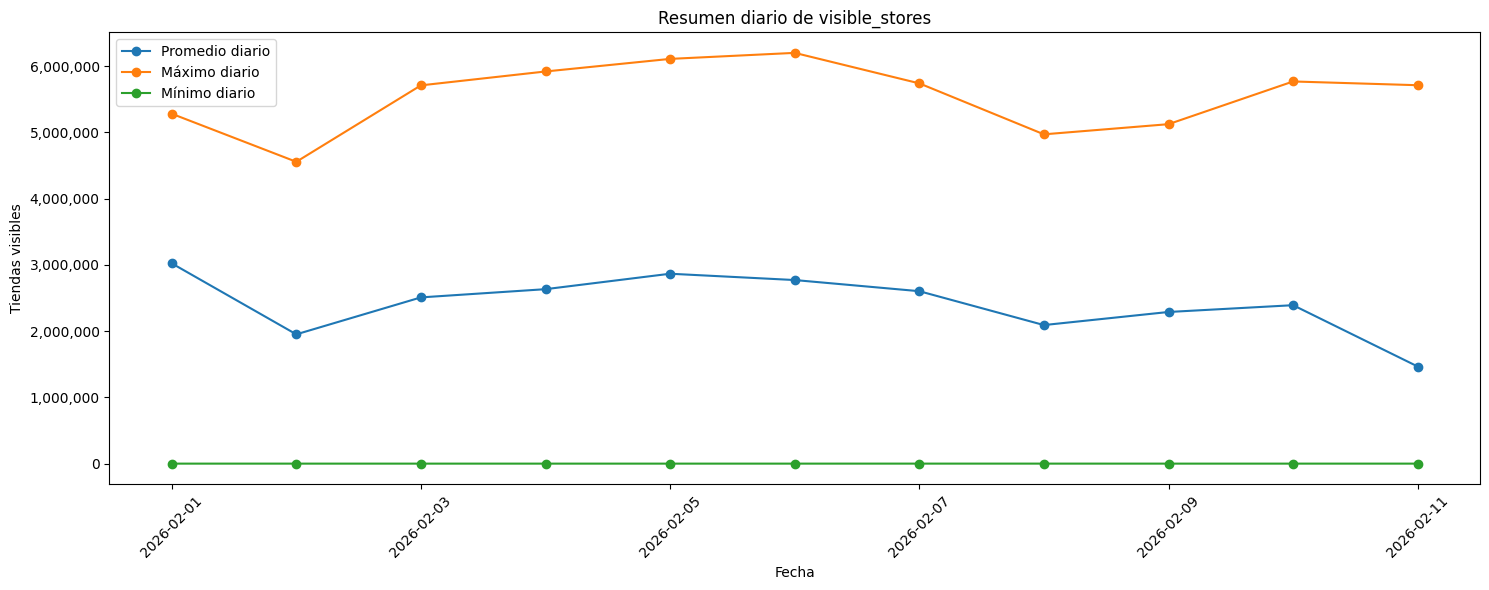

In [29]:
daily = df.groupby("date")["visible_stores"].agg(
    mean="mean",
    median="median",
    min="min",
    max="max",
    std="std",
    count="count"
).reset_index()

daily["range"] = daily["max"] - daily["min"]
daily["cv"] = daily["std"] / daily["mean"] * 100

print("Resumen por día")
print(daily.to_string(index=False))

plt.figure(figsize=(15,6))
plt.plot(daily["date"], daily["mean"], marker="o", label="Promedio diario")
plt.plot(daily["date"], daily["max"], marker="o", label="Máximo diario")
plt.plot(daily["date"], daily["min"], marker="o", label="Mínimo diario")

plt.title("Resumen diario de visible_stores")
plt.xlabel("Fecha")
plt.ylabel("Tiendas visibles")
plt.xticks(rotation=45)
plt.legend()
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)
plt.tight_layout()
plt.show()


Promedio por hora
 hour         mean       median          std
    0 1.734254e+05 4.884075e+03 3.725129e+05
    1 9.005064e+04 2.971610e+03 2.573503e+05
    2 7.086087e+04 2.324906e+03 2.027422e+05
    3 5.167111e+04 1.678203e+03 1.482428e+05
    4 3.248135e+04 1.036644e+03 9.404162e+04
    5 1.329158e+04 3.873251e+02 4.132865e+04
    6 1.125020e+04 1.281100e+04 7.177482e+03
    7 3.769214e+04 3.674200e+04 7.365907e+03
    8 3.682074e+05 3.454370e+05 1.081452e+05
    9 1.234260e+06 1.223142e+06 2.932355e+05
   10 2.154596e+06 2.181833e+06 3.225472e+05
   11 2.883113e+06 2.936762e+06 3.602812e+05
   12 3.726390e+06 3.849822e+06 4.221322e+05
   13 4.510963e+06 4.683030e+06 4.411511e+05
   14 5.158840e+06 5.278251e+06 4.524321e+05
   15 5.199630e+06 5.517693e+06 9.097973e+05
   16 5.146310e+06 5.573400e+06 1.001908e+06
   17 5.247763e+06 5.485212e+06 6.340199e+05
   18 4.983317e+06 5.199530e+06 6.663265e+05
   19 4.803552e+06 4.996215e+06 6.177442e+05
   20 4.482142e+06 4.606204e+06 5.533

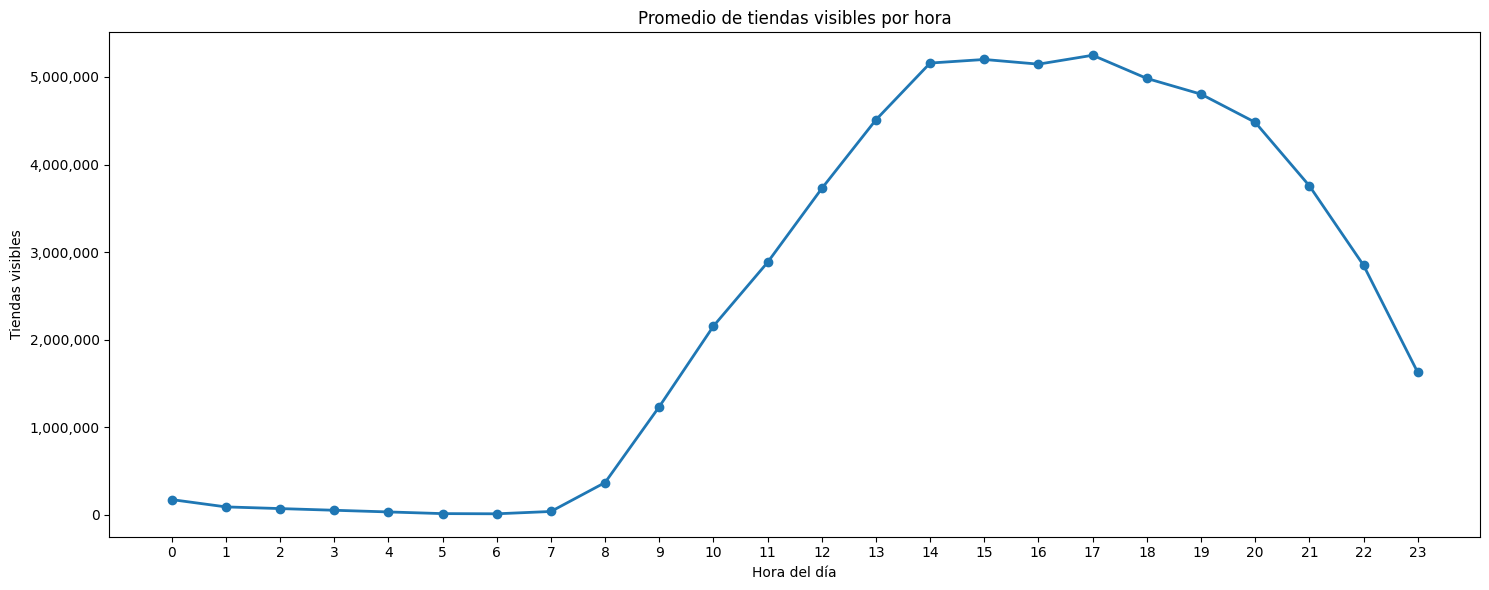

In [25]:
hourly = df.groupby("hour")["visible_stores"].agg(
    mean="mean",
    median="median",
    std="std"
).reset_index()

print("Promedio por hora")
print(hourly.to_string(index=False))

plt.figure(figsize=(15,6))
plt.plot(hourly["hour"], hourly["mean"], marker="o", linewidth=2)

plt.title("Promedio de tiendas visibles por hora")
plt.xlabel("Hora del día")
plt.ylabel("Tiendas visibles")
plt.xticks(range(0,24))
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)
plt.tight_layout()
plt.show()


Promedio por día de la semana
day_of_week  visible_stores
     Monday    2.119742e+06
    Tuesday    2.449664e+06
  Wednesday    2.183677e+06
   Thursday    2.865579e+06
     Friday    2.770382e+06
   Saturday    2.602155e+06
     Sunday    2.487744e+06


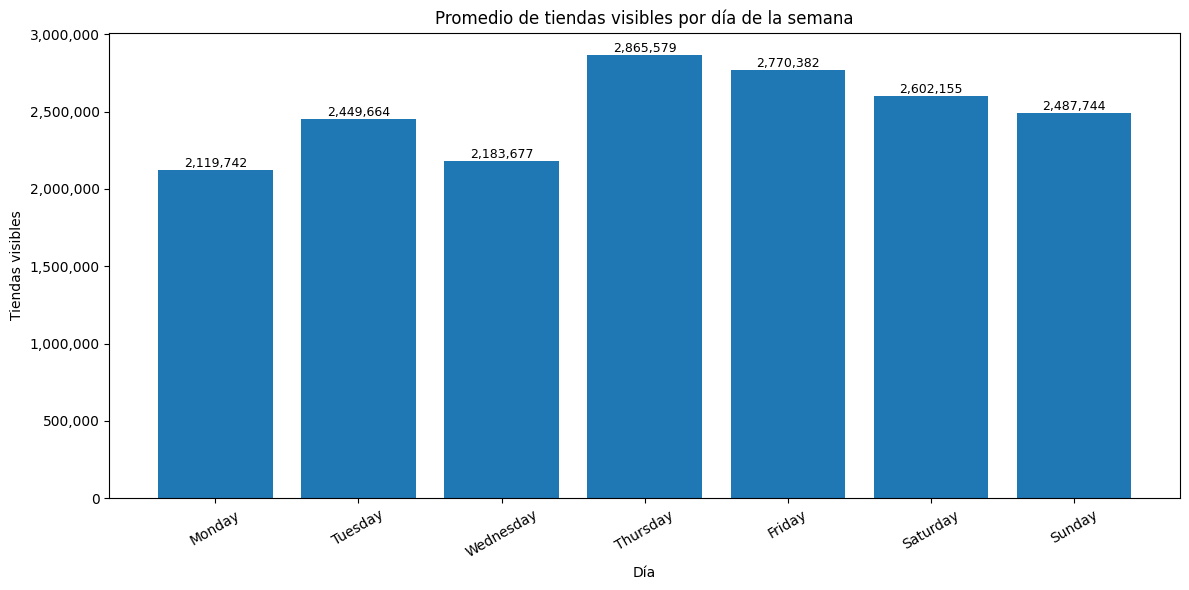

In [27]:
dow = df.groupby(
    ["day_of_week_num", "day_of_week"]
)["visible_stores"].mean().reset_index()

dow = dow.sort_values("day_of_week_num")

print("Promedio por día de la semana")
print(dow[["day_of_week", "visible_stores"]].to_string(index=False))

plt.figure(figsize=(12,6))
bars = plt.bar(dow["day_of_week"], dow["visible_stores"])

plt.title("Promedio de tiendas visibles por día de la semana")
plt.xlabel("Día")
plt.ylabel("Tiendas visibles")
plt.xticks(rotation=30)

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

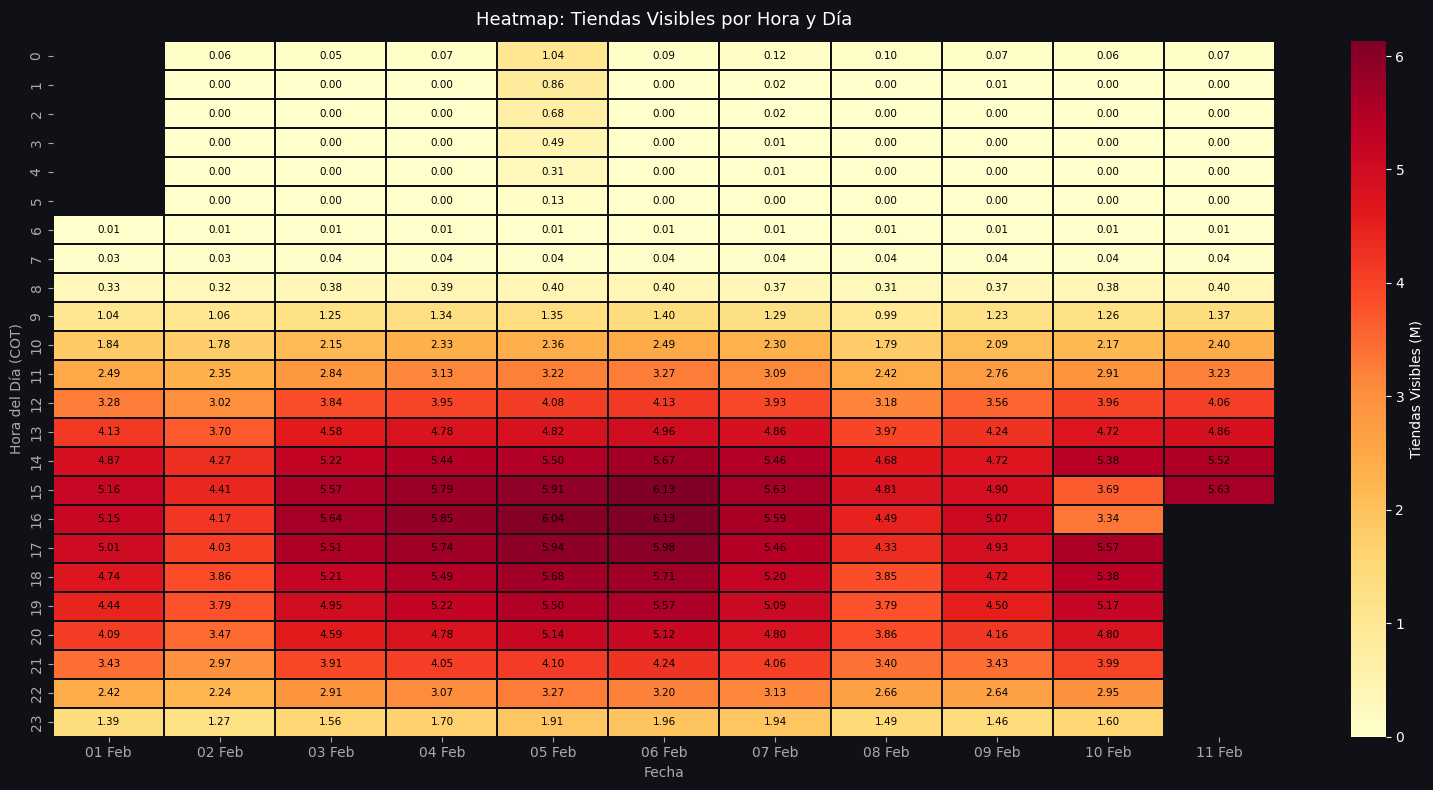

In [30]:
pivot = df.pivot_table(
    values="visible_stores",
    index="hour",
    columns="date_str",
    aggfunc="mean"
)

date_order = df.groupby("date_str")["timestamp"].min().sort_values().index.tolist()
pivot = pivot.reindex(columns=[d for d in date_order if d in pivot.columns])

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

sns.heatmap(
    pivot / 1e6,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="#0f1117",
    fmt=".2f",
    annot=True,
    annot_kws={"size": 7.5, "color": "black"},
    cbar_kws={"label": "Tiendas Visibles (M)"}
)

ax.set_title("Heatmap: Tiendas Visibles por Hora y Día",
             color="white", fontsize=13, pad=12)
ax.set_xlabel("Fecha", color="#aaaaaa")
ax.set_ylabel("Hora del Día (COT)", color="#aaaaaa")
ax.tick_params(colors="#aaaaaa")

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color("white")
cbar.ax.tick_params(colors="white")

plt.tight_layout()
plt.savefig("plot_heatmap.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

In [31]:
import plotly.graph_objects as go

significant_drops = anomalies_drop[
    anomalies_drop["pct_change_1min"] < -2.0
].copy()

# Figura
fig = go.Figure()

# Serie principal
fig.add_trace(
    go.Scatter(
        x=df["timestamp"],
        y=df["visible_stores"],
        mode="lines",
        name="Tiendas Visibles",
        line=dict(width=1.5),
        hovertemplate=
        "<b>%{x}</b><br>" +
        "Visible Stores: %{y:,.0f}<extra></extra>"
    )
)

if len(significant_drops) > 0:
    fig.add_trace(
        go.Scatter(
            x=significant_drops["timestamp"],
            y=significant_drops["visible_stores"],
            mode="markers",
            name="Caídas >2% en 1 min",
            marker=dict(
                size=9,
                symbol="triangle-down",
                color="red",
                line=dict(width=1)
            ),
            hovertemplate=
            "<b>%{x}</b><br>" +
            "Visible Stores: %{y:,.0f}<br>" +
            "Cambio 1min: %{customdata:.2f}%<extra></extra>",
            customdata=significant_drops["pct_change_1min"]
        )
    )

fig.update_layout(
    title="Dashboard de Anomalías — Caídas Bruscas de Disponibilidad",
    template="plotly_white",
    height=700,
    hovermode="x unified",
    xaxis=dict(
        title="Fecha / Hora",
        rangeslider=dict(visible=True),
        type="date"
    ),
    yaxis=dict(
        title="Tiendas Visibles",
        separatethousands=True
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    )
)

fig.show()